<a href="https://colab.research.google.com/github/lavanyar866811-pixel/demo/blob/main/KAN_WITH_RESNET50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle torch torchvision scikit-learn tqdm seaborn matplotlib

import os, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

In [ ]:

kaggle_username = "Lavanya245214121"
kaggle_key = "KGAT_b044123af5b148f8d9a5002d88a03ab3"
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json","w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -oq skin-cancer-mnist-ham10000.zip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [04:20<00:00, 117MB/s] 
100% 5.20G/5.20G [04:20<00:00, 21.4MB/s]


In [ ]:
metadata = pd.read_csv("HAM10000_metadata.csv")
metadata["label"] = metadata["dx"].apply(lambda x: "malignant" if x=="mel" else "benign")

base_dir = "skin_binary"
os.makedirs(base_dir, exist_ok=True)

for _, row in metadata.iterrows():
    img = row["image_id"] + ".jpg"
    label = row["label"]

    dst = os.path.join(base_dir, label)
    os.makedirs(dst, exist_ok=True)

    p1 = os.path.join("HAM10000_images_part_1", img)
    p2 = os.path.join("HAM10000_images_part_2", img)

    src = p1 if os.path.exists(p1) else p2 if os.path.exists(p2) else None

    if src:
        shutil.copy(src, os.path.join(dst, img))

print("Dataset Ready")


Dataset Ready


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = ImageFolder(base_dir)

train_idx, val_idx = train_test_split(
    np.arange(len(dataset)),
    test_size=0.2,
    stratify=dataset.targets,
    random_state=seed
)

train_loader = DataLoader(
    ImageFolder(base_dir, transform=train_transform),
    batch_size=32,
    sampler=torch.utils.data.SubsetRandomSampler(train_idx),
    num_workers=2
)

val_loader = DataLoader(
    ImageFolder(base_dir, transform=val_transform),
    batch_size=32,
    sampler=torch.utils.data.SubsetRandomSampler(val_idx),
    num_workers=2
)


In [ ]:
class KANFusion(nn.Module):
    def __init__(self, f1_dim, f2_dim, hidden_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(f1_dim, hidden_dim)
        self.fc2 = nn.Linear(f2_dim, hidden_dim)
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self,f1,f2):
        h1 = torch.tanh(self.fc1(f1))
        h2 = torch.tanh(self.fc2(f2))
        a1 = torch.sigmoid(self.attn(h1))
        a2 = torch.sigmoid(self.attn(h2))
        return a1*h1 + a2*h2

In [ ]:
class HybridResNet50KAN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)

        self.layer0 = nn.Sequential(
            resnet.conv1, resnet.bn1,
            resnet.relu, resnet.maxpool
        )
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.kan = KANFusion(1024,2048,512)

        self.classifier = nn.Sequential(
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256,2)
        )

    def forward(self,x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        f1 = self.layer3(x)
        f2 = self.layer4(f1)

        f1 = self.avgpool(f1).flatten(1)
        f2 = self.avgpool(f2).flatten(1)

        fused = self.kan(f1,f2)
        return self.classifier(fused)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce = self.ce(inputs, targets)
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()


In [ ]:
model = HybridResNet50KAN().to(device)
criterion = FocalLoss(gamma=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s]


In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

best_f1 = 0
num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_idx)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:,1]
            _, preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_idx)
    val_losses.append(epoch_val_loss)

    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    val_f1 = f1_score(all_labels, all_preds)
    val_auc = roc_auc_score(all_labels, all_probs)

    scheduler.step()

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"F1: {val_f1:.4f} | "
          f"AUC: {val_auc:.4f}")

Epoch [1/20] | Train Loss: 0.0700 | Val Loss: 0.0583 | Val Acc: 0.8982 | F1: 0.1774 | AUC: 0.9183
Epoch [2/20] | Train Loss: 0.0539 | Val Loss: 0.0471 | Val Acc: 0.9256 | F1: 0.6069 | AUC: 0.9428
Epoch [3/20] | Train Loss: 0.0433 | Val Loss: 0.0480 | Val Acc: 0.9271 | F1: 0.5989 | AUC: 0.9422
Epoch [4/20] | Train Loss: 0.0323 | Val Loss: 0.0577 | Val Acc: 0.9086 | F1: 0.6376 | AUC: 0.9345
Epoch [5/20] | Train Loss: 0.0278 | Val Loss: 0.0551 | Val Acc: 0.9261 | F1: 0.5795 | AUC: 0.9457
Epoch [6/20] | Train Loss: 0.0201 | Val Loss: 0.0846 | Val Acc: 0.9271 | F1: 0.5922 | AUC: 0.9353
Epoch [7/20] | Train Loss: 0.0143 | Val Loss: 0.0703 | Val Acc: 0.9296 | F1: 0.6651 | AUC: 0.9460
Epoch [8/20] | Train Loss: 0.0125 | Val Loss: 0.0799 | Val Acc: 0.9281 | F1: 0.5789 | AUC: 0.9388
Epoch [9/20] | Train Loss: 0.0099 | Val Loss: 0.0745 | Val Acc: 0.9331 | F1: 0.6398 | AUC: 0.9449
Epoch [10/20] | Train Loss: 0.0058 | Val Loss: 0.0736 | Val Acc: 0.9346 | F1: 0.6874 | AUC: 0.9555
Epoch [11/20] | Tra

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n===== FINAL METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)




===== FINAL METRICS =====
Accuracy  : 0.9396
Precision : 0.8228
Recall    : 0.5830
F1 Score  : 0.6824
AUC Score : 0.9600

Confusion Matrix:
 [[1752   28]
 [  93  130]]


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def analyze_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)

    print("\n===== CLASSIFICATION REPORT ANALYSIS =====")

    for cls in report:
        if cls.isdigit():  # class-specific metrics
            precision = report[cls]['precision']
            recall = report[cls]['recall']
            f1 = report[cls]['f1-score']
            support = report[cls]['support']

            print(f"\n--- Class {cls} Analysis ---")
            print(f"• Precision: {precision:.4f} → "
                  f"{'High (few false positives)' if precision > 0.8 else 'Low (more false positives)'}")
            print(f"• Recall:    {recall:.4f} → "
                  f"{'High (few false negatives)' if recall > 0.8 else 'Low (more false negatives)'}")
            print(f"• F1 Score:  {f1:.4f} → "
                  f"{'Balanced performance' if f1 > 0.8 else 'Needs improvement'}")
            print(f"• Support:   {support} samples")


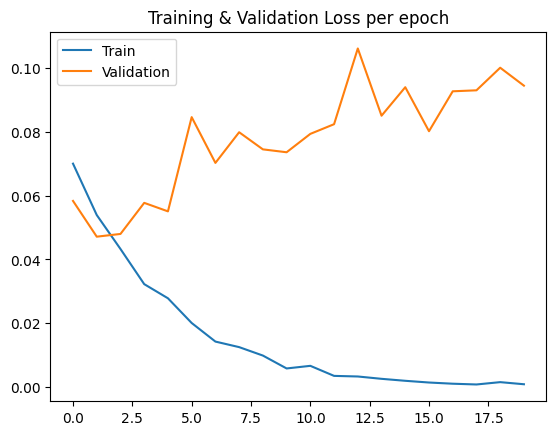

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Training & Validation Loss per epoch")
plt.legend(["Train","Validation"])
plt.show()



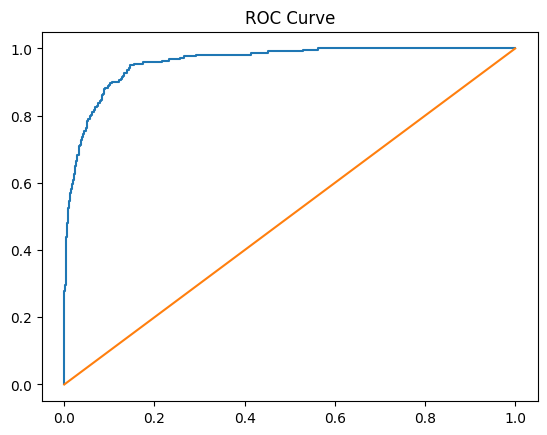

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.show()

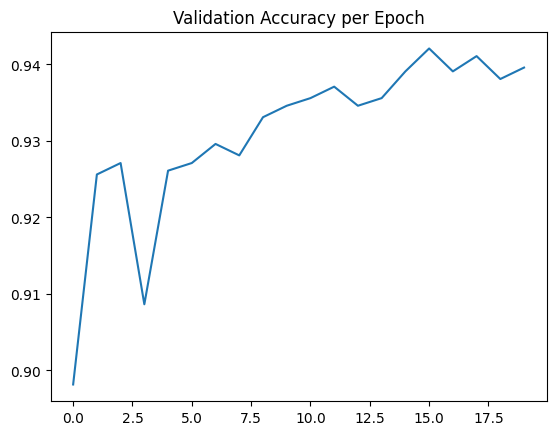

In [ ]:
plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy per Epoch")
plt.show()

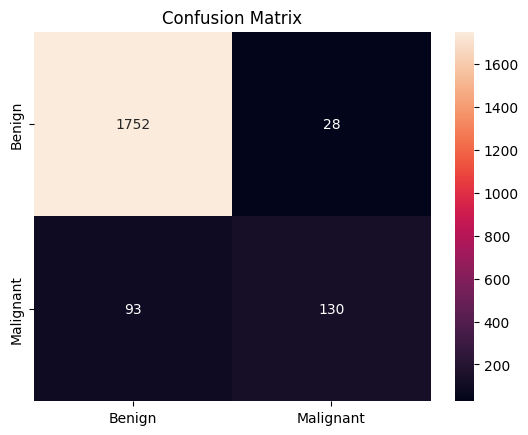

In [ ]:

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.title("Confusion Matrix")
plt.show()